6 fichier(s) trouve(s)

   dataset_A_20260110_093406.csv: 527 lignes
   dataset_B_20260110_112657.csv: 534 lignes
   dataset_D_20260110_114323.csv: 528 lignes
   dataset_F_20260110_115121.csv: 533 lignes
   dataset_OK_20260110_121116.csv: 521 lignes
   dataset_STOP_20260110_112115.csv: 530 lignes

Dataset total: 3173 echantillons

INFORMATIONS GENERALES
Nombre total d'echantillons: 3173
Nombre de colonnes: 12
Colonnes: timestamp, flex_thumb, flex_index, flex_middle, gyro_x, gyro_y, gyro_z, accel_x, accel_y, accel_z, label, datetime

DISTRIBUTION DES GESTES

| Geste     | Nombre d'echantillons | Pourcentage |
|-----------|----------------------|-------------|
| A         | 527                  |  16.61%    |
| B         | 534                  |  16.83%    |
| D         | 528                  |  16.64%    |
| F         | 533                  |  16.80%    |
| OK        | 521                  |  16.42%    |
| STOP      | 530                  |  16.70%    |
| TOTAL     | 3173               

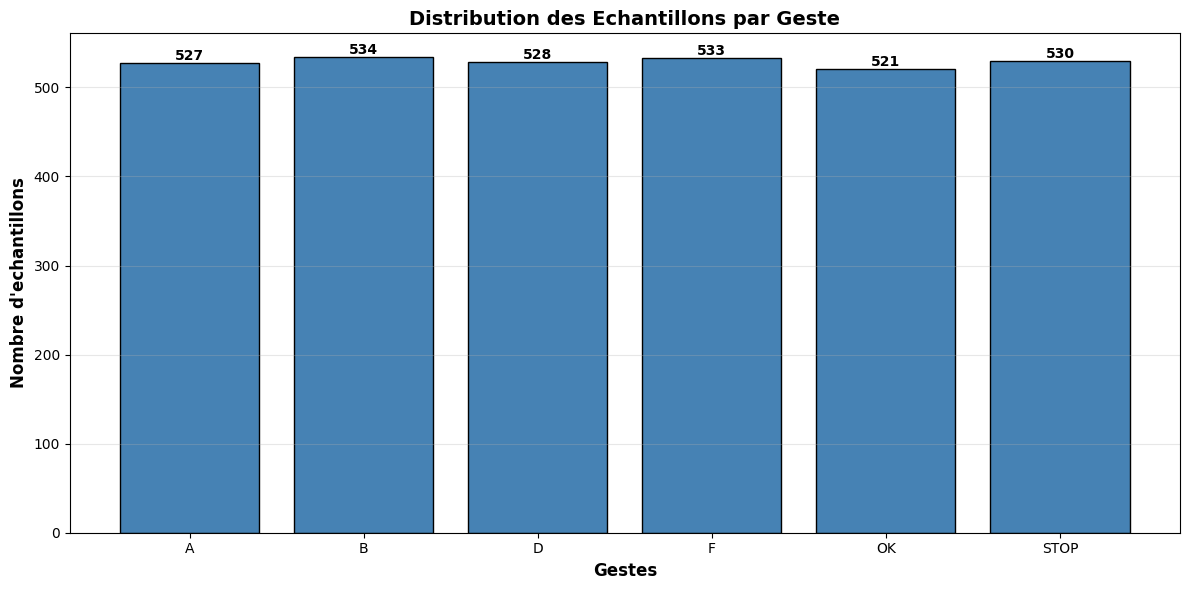

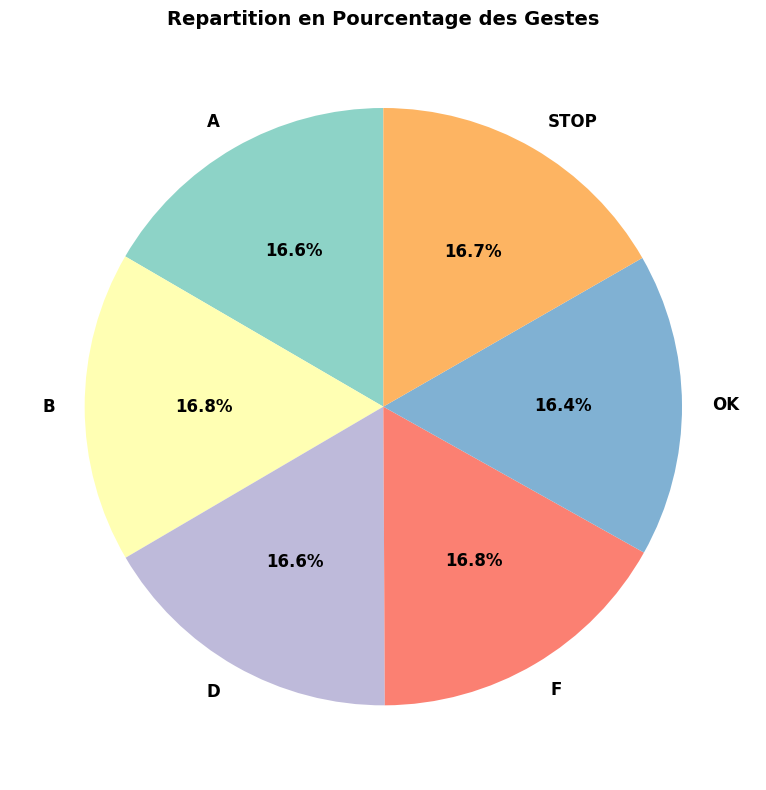

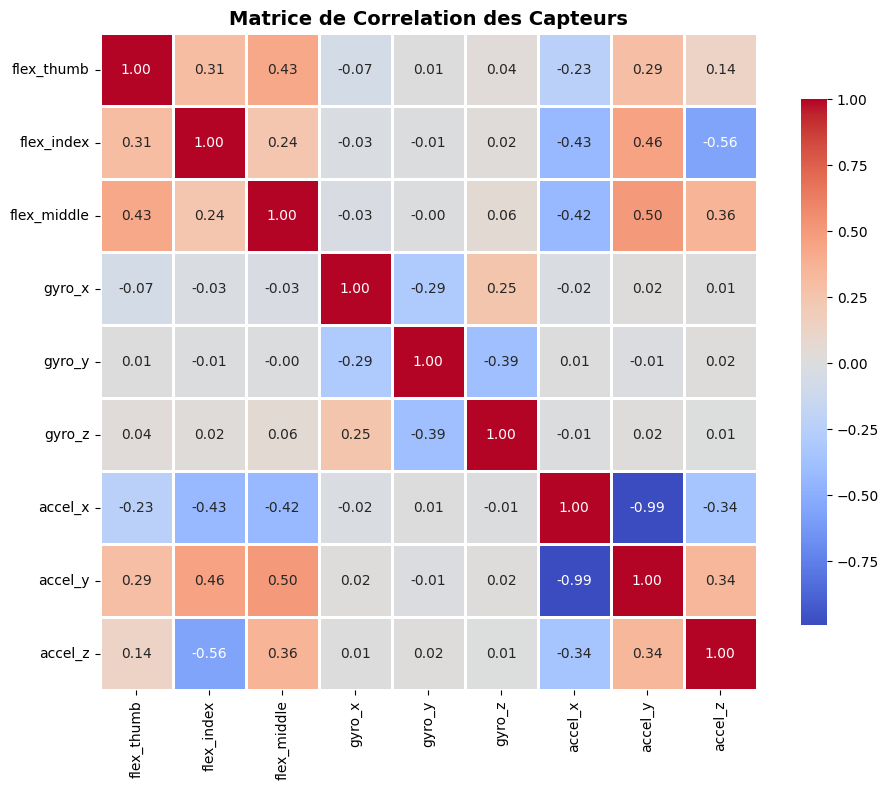

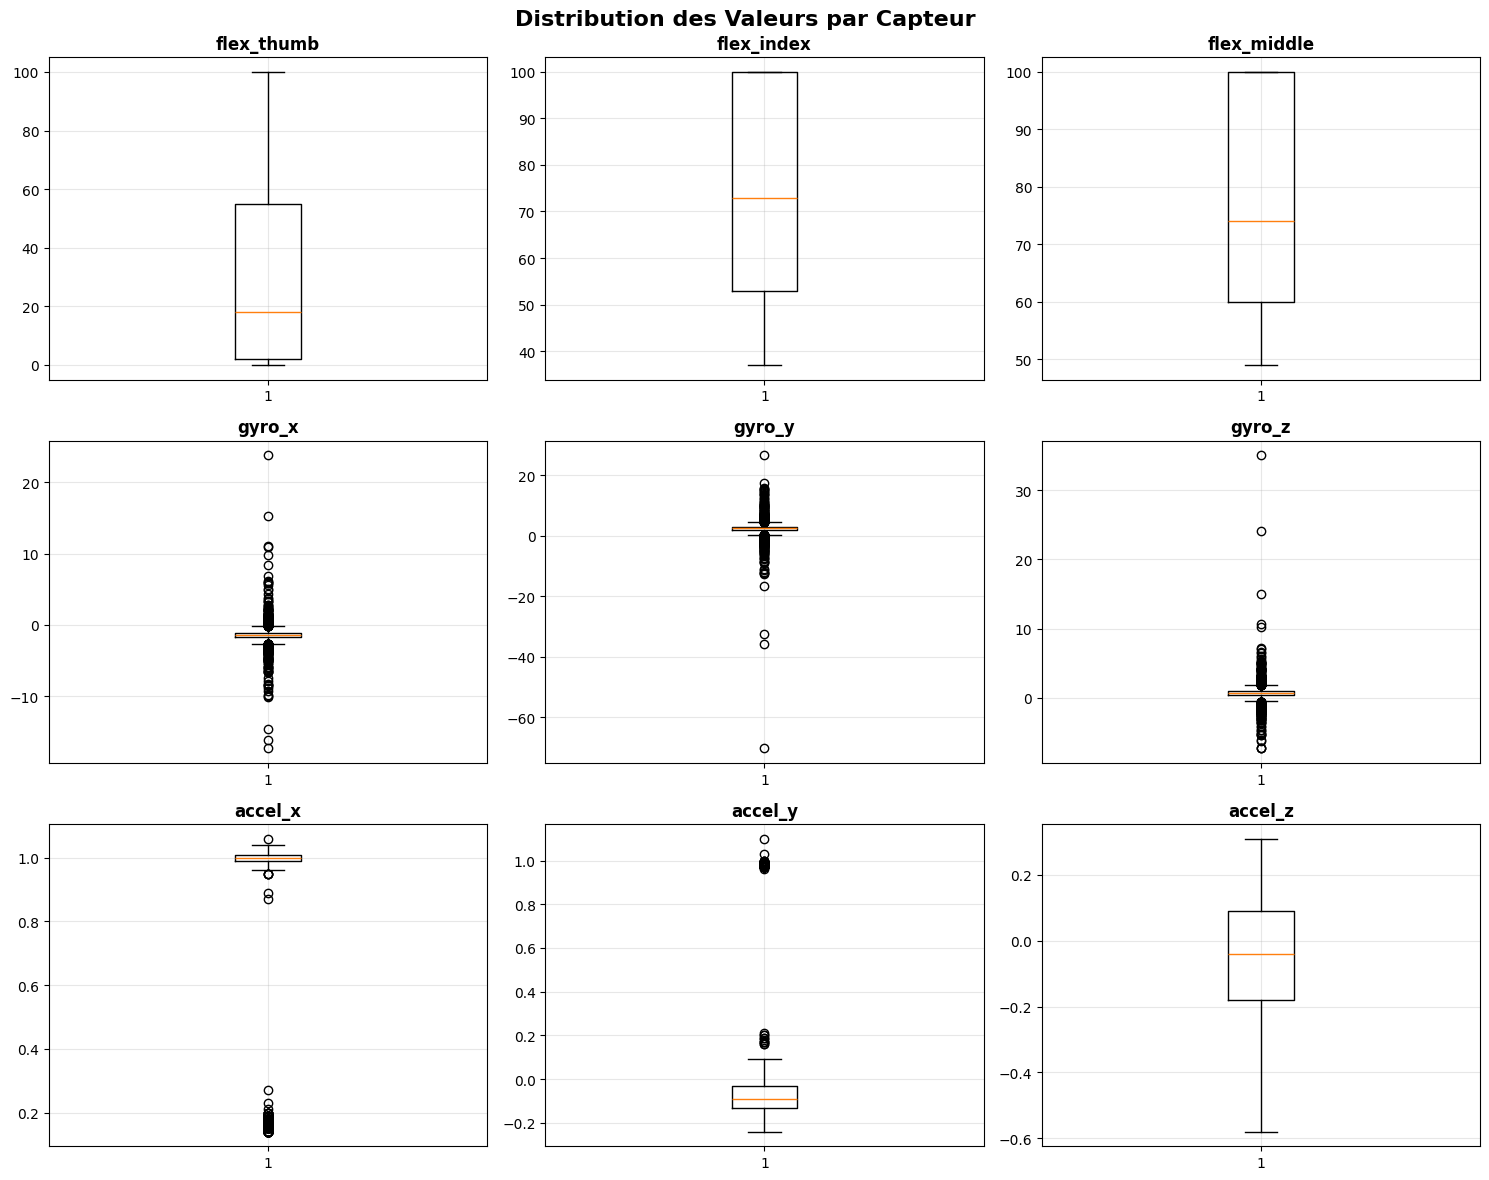

In [1]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Charger tous les CSV
DATASET_FOLDER = "datasets"
csv_files = glob.glob(os.path.join(DATASET_FOLDER, "*.csv"))

if not csv_files:
    print("Aucun fichier CSV trouve dans", DATASET_FOLDER)
    exit(1)

print(f"{len(csv_files)} fichier(s) trouve(s)\n")

# Fusionner tous les CSV
dataframes = []
for file in csv_files:
    df = pd.read_csv(file)
    dataframes.append(df)
    print(f"   {os.path.basename(file)}: {len(df)} lignes")

data = pd.concat(dataframes, ignore_index=True)
print(f"\nDataset total: {len(data)} echantillons\n")

# Informations générales
print("="*70)
print("INFORMATIONS GENERALES")
print("="*70)
print(f"Nombre total d'echantillons: {len(data)}")
print(f"Nombre de colonnes: {len(data.columns)}")
print(f"Colonnes: {', '.join(data.columns)}\n")

# Distribution des gestes
print("="*70)
print("DISTRIBUTION DES GESTES")
print("="*70 + "\n")

geste_counts = data['label'].value_counts().sort_index()
total = len(data)

print("| Geste     | Nombre d'echantillons | Pourcentage |")
print("|-----------|----------------------|-------------|")
for geste, count in geste_counts.items():
    pct = (count / total * 100)
    print(f"| {geste:<9} | {count:<20} | {pct:>6.2f}%    |")
print(f"| TOTAL     | {total:<20} | 100.00%     |")

# Analyse de l'équilibre
print("\n" + "="*70)
print("ANALYSE DE L'EQUILIBRE")
print("="*70)

min_count = geste_counts.min()
max_count = geste_counts.max()
variation = ((max_count - min_count) / min_count * 100)

print(f"\nGeste le moins represente: {geste_counts.idxmin()} ({min_count} echantillons)")
print(f"Geste le plus represente: {geste_counts.idxmax()} ({max_count} echantillons)")
print(f"Variation: {variation:.1f}%\n")

if variation < 20:
    print("Dataset EQUILIBRE (variation < 20%)")
elif variation < 50:
    print("Dataset LEGEREMENT DESEQUILIBRE (20% < variation < 50%)")
else:
    print("Dataset DESEQUILIBRE (variation > 50%)")

# Statistiques des capteurs
print("\n" + "="*70)
print("STATISTIQUES DES CAPTEURS")
print("="*70 + "\n")

feature_columns = [
    'flex_thumb', 'flex_index', 'flex_middle',
    'gyro_x', 'gyro_y', 'gyro_z',
    'accel_x', 'accel_y', 'accel_z'
]

stats = data[feature_columns].describe()
print(stats.round(2))

# Valeurs manquantes
print("\n" + "="*70)
print("VALEURS MANQUANTES")
print("="*70 + "\n")

missing = data.isnull().sum()
if missing.sum() == 0:
    print("Aucune valeur manquante detectee")
else:
    print(missing[missing > 0])

# Génération des graphiques
print("\n" + "="*70)
print("GENERATION DES GRAPHIQUES")
print("="*70 + "\n")

# 1. Distribution des gestes
plt.figure(figsize=(12, 6))
bars = plt.bar(geste_counts.index, geste_counts.values, color='steelblue', edgecolor='black')
plt.xlabel('Gestes', fontsize=12, fontweight='bold')
plt.ylabel('Nombre d\'echantillons', fontsize=12, fontweight='bold')
plt.title('Distribution des Echantillons par Geste', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('distribution_gestes.png', dpi=300)
print("Sauvegarde: distribution_gestes.png")

# 2. Graphique circulaire
plt.figure(figsize=(10, 8))
colors = plt.cm.Set3(range(len(geste_counts)))
plt.pie(geste_counts.values, labels=geste_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors, textprops={'fontsize': 12, 'fontweight': 'bold'})
plt.title('Repartition en Pourcentage des Gestes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('repartition_gestes.png', dpi=300)
print("Sauvegarde: repartition_gestes.png")

# 3. Heatmap de corrélation
plt.figure(figsize=(10, 8))
correlation = data[feature_columns].corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matrice de Correlation des Capteurs', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_capteurs.png', dpi=300)
print("Sauvegarde: correlation_capteurs.png")

# 4. Boxplot
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribution des Valeurs par Capteur', fontsize=16, fontweight='bold')

for idx, col in enumerate(feature_columns):
    row = idx // 3
    col_idx = idx % 3
    axes[row, col_idx].boxplot(data[col].dropna())
    axes[row, col_idx].set_title(col, fontweight='bold')
    axes[row, col_idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('boxplot_capteurs.png', dpi=300)
print("Sauvegarde: boxplot_capteurs.png")

# Résumé final
print("\n" + "="*70)
print("ANALYSE TERMINEE")
print("="*70)
print("\nFichiers generes:")
print("   - distribution_gestes.png")
print("   - repartition_gestes.png")
print("   - correlation_capteurs.png")
print("   - boxplot_capteurs.png")